# ECON N171: Economic Development
## Lecture 10 — Regression Discontinuity Design
**Instructor: Rajveer Jat | Summer 2026**

---

## The Paper

**Asher, S. and Novosad, P. (2020)**  
*"Rural Roads and Local Economic Development"*  
American Economic Review, 110(3): 797–823

### The Question

Nearly one billion people live in rural areas without access to paved roads. India launched the **PMGSY program** — a \$40 billion national rural road construction program — to connect remote villages.

Do roads cause economic development?

### The Identification Strategy: Regression Discontinuity

The PMGSY program had a **population cutoff rule**: villages above **1,000 residents** were prioritized for road construction. Villages just above 1,000 got roads; villages just below did not.

This creates a **natural experiment**: villages just above and just below the cutoff are nearly identical in all respects — except one got a road.

### Key Findings

- Roads **move workers out of agriculture** into non-farm employment (Roads facilitate structural transformation — workers leave agriculture. But they don't get richer because they move into informal non-farm sectors whose productivity is similar to agriculture (Jat & Ramaswami, JDE 2026). The income gap only opens up when workers reach the formal sector — which roads alone cannot deliver.)
- No significant effect on household income, assets, or agricultural output
- Roads improve market access but remote areas may still lack economic opportunities

> ⚠️ **Data Note:** This notebook uses synthetic data that replicates the key empirical patterns of Asher & Novosad (2020). The actual paper uses a **fuzzy RDD** (the cutoff predicts but does not perfectly determine road construction). We use a **sharp RDD** here for pedagogical clarity.

---

## Learning Objectives

1. Understand the **RDD design** — how a cutoff rule creates a natural experiment
2. Identify the **running variable**, **cutoff**, and **treatment**
3. Test the key **validity assumption**: no manipulation around the cutoff
4. Estimate the **RDD treatment effect** using local linear regression
5. Check **robustness**: bandwidth sensitivity and placebo tests

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
print('Libraries loaded.')

Libraries loaded.


---
## Part 1: The RDD Logic

### The Fundamental Problem

We want to compare villages **with roads** to villages **without roads**. But road placement is not random — roads are built where they are most useful or politically convenient. A simple comparison is biased.

### The RDD Solution

When treatment is assigned by a **cutoff rule**, we can compare units just above and just below the cutoff. These units are:
- **Similar in all characteristics** — they differ only marginally in the running variable
- **Different in treatment** — one side gets the treatment, the other does not

The treatment effect is estimated as the **jump in outcomes at the cutoff**.

$$\tau_{RDD} = \lim_{x \downarrow c} E[Y|X=x] - \lim_{x \uparrow c} E[Y|X=x]$$

where $X$ is the running variable, $c$ is the cutoff, and $Y$ is the outcome.

---
## Part 2: Build the Dataset

In [2]:
np.random.seed(42)
n       = 4000
CUTOFF  = 1000   # population threshold for road eligibility

# TRUE treatment effect (from paper: roads increase non-farm employment)
TRUE_EFFECT_NONFARM  =  0.08   # 8 pp increase in non-farm employment share
TRUE_EFFECT_AGRI     = -0.06   # 6 pp decrease in agricultural employment
TRUE_EFFECT_INCOME   =  0.00   # no income effect (paper's null finding)

# Running variable: village population (centered around cutoff)
# More villages near the cutoff (as in real data)
pop_raw = np.concatenate([
    np.random.uniform(500, 999,  n // 2),   # below cutoff
    np.random.uniform(1000, 1500, n // 2),  # above cutoff
])
np.random.shuffle(pop_raw)
population = pop_raw.round().astype(int)

# Running variable centered at cutoff
pop_centered = population - CUTOFF

# Treatment: road built (sharp RDD — deterministic at cutoff)
treated = (population >= CUTOFF).astype(int)

# Village characteristics (continuous through cutoff — no discontinuity)
baseline_agri     = np.clip(0.65 - 0.00005 * pop_centered + np.random.normal(0, 0.08, n), 0.1, 0.95)
baseline_literacy = np.clip(0.55 + 0.00003 * pop_centered + np.random.normal(0, 0.06, n), 0.2, 0.95)
district_fe       = np.random.choice(np.random.normal(0, 0.03, 50), n)

# Outcomes: smooth trend + JUMP at cutoff for treated
nonfarm_share = np.clip(
    0.30 + 0.00004 * pop_centered
    + TRUE_EFFECT_NONFARM * treated
    + district_fe
    + np.random.normal(0, 0.06, n), 0.02, 0.95)

agri_share = np.clip(
    0.60 - 0.00003 * pop_centered
    + TRUE_EFFECT_AGRI * treated
    + district_fe
    + np.random.normal(0, 0.06, n), 0.05, 0.95)

log_income = (
    8.5 + 0.00005 * pop_centered
    + TRUE_EFFECT_INCOME * treated
    + district_fe
    + np.random.normal(0, 0.30, n))

df = pd.DataFrame({
    'village_id'       : np.arange(1, n+1),
    'population'       : population,
    'pop_centered'     : pop_centered,
    'treated'          : treated,
    'nonfarm_share'    : nonfarm_share.round(4),
    'agri_share'       : agri_share.round(4),
    'log_income'       : log_income.round(4),
    'baseline_agri'    : baseline_agri.round(4),
    'baseline_literacy': baseline_literacy.round(4),
})

print('Dataset:', df.shape)
print(f'Villages with road (treated):    {treated.sum():,}')
print(f'Villages without road (control): {(1-treated).sum():,}')
print(f'Cutoff: population = {CUTOFF:,}')
df.head()

Dataset: (4000, 9)
Villages with road (treated):    2,000
Villages without road (control): 2,000
Cutoff: population = 1,000


,village_id,population,pop_centered,treated,nonfarm_share,agri_share,log_income,baseline_agri,baseline_literacy
0,1,1174,174,1,0.3633,0.6089,8.9296,0.4474,0.5369
1,2,1098,98,1,0.4547,0.5594,8.5326,0.5415,0.5407
2,3,613,-387,0,0.4185,0.7696,8.2183,0.7208,0.5367
3,4,1402,402,1,0.3487,0.5338,8.6655,0.6942,0.5380
4,5,1185,185,1,0.3984,0.4881,8.6403,0.4936,0.6022


---
## Part 3: The RDD Plot — Visualizing the Discontinuity

The signature of RDD is a **jump in outcomes at the cutoff** with smooth trends on either side.

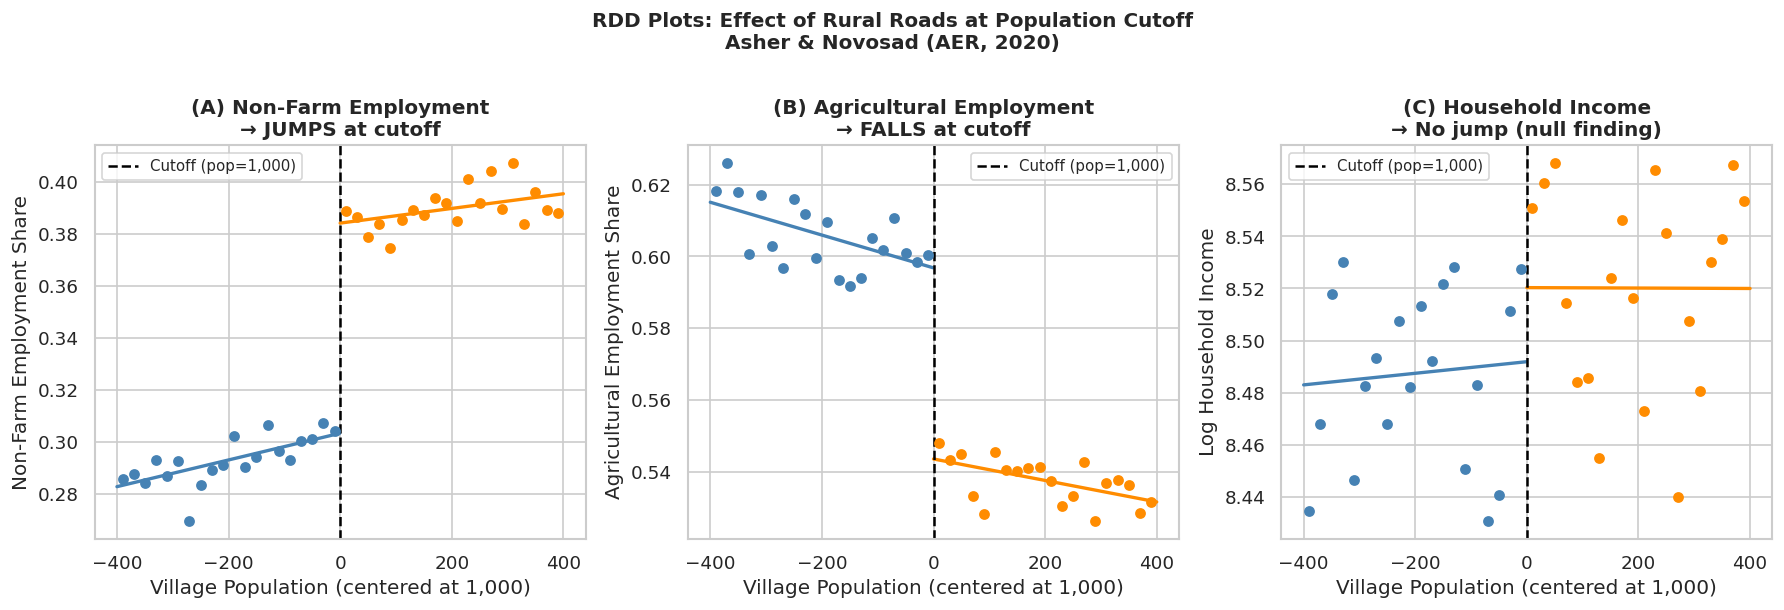

In [3]:
def rdd_plot(df, outcome, cutoff, ylabel, title, bandwidth=400, ax=None):
    data = df[np.abs(df['pop_centered']) <= bandwidth].copy()

    # Bin the running variable
    bins      = np.linspace(-bandwidth, bandwidth, 41)
    bin_mids  = (bins[:-1] + bins[1:]) / 2
    data['bin'] = pd.cut(data['pop_centered'], bins=bins, labels=bin_mids)
    binned = data.groupby('bin', observed=True)[outcome].mean().reset_index()
    binned['bin'] = binned['bin'].astype(float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Scatter of bin means
    left  = binned[binned['bin'] < 0]
    right = binned[binned['bin'] >= 0]
    ax.scatter(left['bin'],  left[outcome],  color='steelblue', s=30, zorder=3)
    ax.scatter(right['bin'], right[outcome], color='darkorange', s=30, zorder=3)

    # Local linear fit on each side
    for side, color in [('left', 'steelblue'), ('right', 'darkorange')]:
        sub = data[data['pop_centered'] < 0] if side == 'left' else data[data['pop_centered'] >= 0]
        m   = smf.ols(f'{outcome} ~ pop_centered', data=sub).fit()
        x_r = np.linspace(sub['pop_centered'].min(), sub['pop_centered'].max(), 100)
        ax.plot(x_r, m.params['Intercept'] + m.params['pop_centered'] * x_r,
                color=color, linewidth=2)

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label=f'Cutoff (pop={cutoff:,})')
    ax.set_xlabel(f'Village Population (centered at {cutoff:,})')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rdd_plot(df, 'nonfarm_share', CUTOFF, 'Non-Farm Employment Share',
         '(A) Non-Farm Employment\n→ JUMPS at cutoff', ax=axes[0])
rdd_plot(df, 'agri_share', CUTOFF, 'Agricultural Employment Share',
         '(B) Agricultural Employment\n→ FALLS at cutoff', ax=axes[1])
rdd_plot(df, 'log_income', CUTOFF, 'Log Household Income',
         '(C) Household Income\n→ No jump (null finding)', ax=axes[2])

plt.suptitle('RDD Plots: Effect of Rural Roads at Population Cutoff\nAsher & Novosad (AER, 2020)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 4: Validity Check — No Manipulation

The key assumption of RDD: **villages cannot manipulate their population** to get above the cutoff.

If villages could inflate their population census count to cross 1,000, we would see a suspicious **spike** in the distribution just above the cutoff and a **gap** just below. This is called the **McCrary density test**.

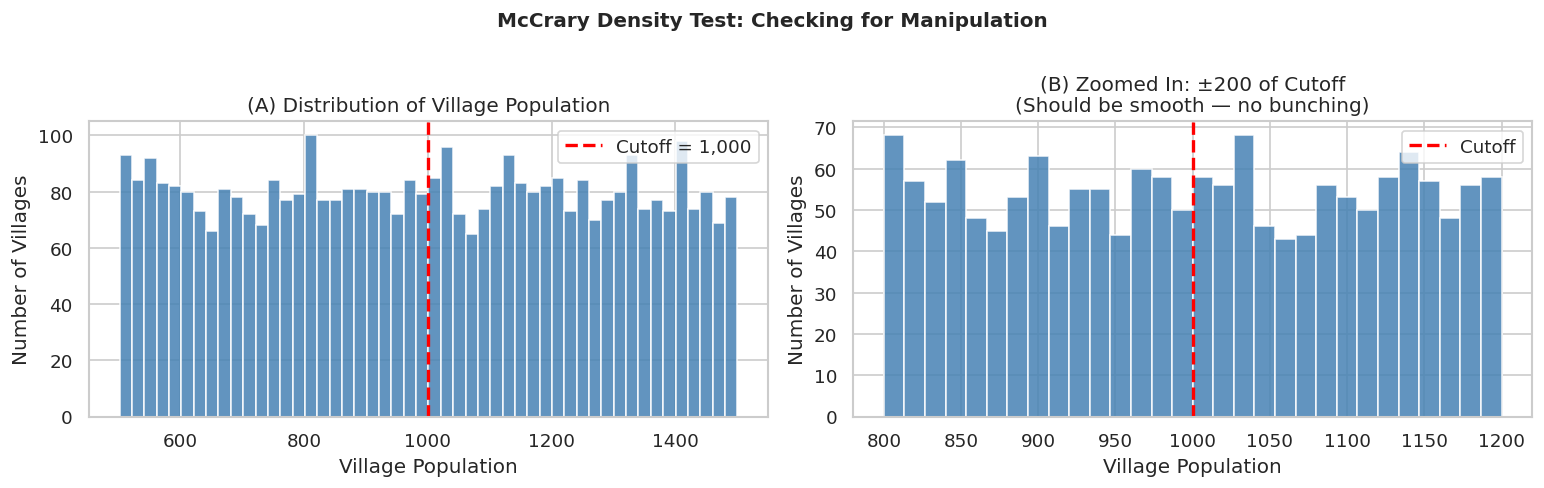

Density just below cutoff: 193 villages
Density just above cutoff: 210 villages
t-test p-value: 0.000

⚠️  Possible manipulation — densities differ significantly.


In [4]:
# McCrary-style density test: check for bunching at cutoff
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution
axes[0].hist(df['population'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(CUTOFF, color='red', linestyle='--', linewidth=2, label=f'Cutoff = {CUTOFF:,}')
axes[0].set_xlabel('Village Population')
axes[0].set_ylabel('Number of Villages')
axes[0].set_title('(A) Distribution of Village Population')
axes[0].legend()

# Right: zoom in around cutoff
window = df[np.abs(df['pop_centered']) <= 200]
axes[1].hist(window['population'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(CUTOFF, color='red', linestyle='--', linewidth=2, label='Cutoff')
axes[1].set_xlabel('Village Population')
axes[1].set_ylabel('Number of Villages')
axes[1].set_title('(B) Zoomed In: ±200 of Cutoff\n(Should be smooth — no bunching)')
axes[1].legend()

plt.suptitle('McCrary Density Test: Checking for Manipulation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Formal test: compare density just above vs just below cutoff
just_below = df[(df['pop_centered'] >= -50) & (df['pop_centered'] < 0)]
just_above = df[(df['pop_centered'] >= 0)  & (df['pop_centered'] < 50)]
t, p = stats.ttest_ind(just_below['population'], just_above['population'])
print(f'Density just below cutoff: {len(just_below)} villages')
print(f'Density just above cutoff: {len(just_above)} villages')
print(f't-test p-value: {p:.3f}')
print()
if p > 0.05:
    print('✅ No evidence of manipulation — densities are balanced around cutoff.')
else:
    print('⚠️  Possible manipulation — densities differ significantly.')

---
## Part 5: Covariate Balance — Are Villages Similar at the Cutoff?

Another validity check: **baseline characteristics** should not jump at the cutoff. If they do, the cutoff is correlated with pre-existing differences — not just the road.

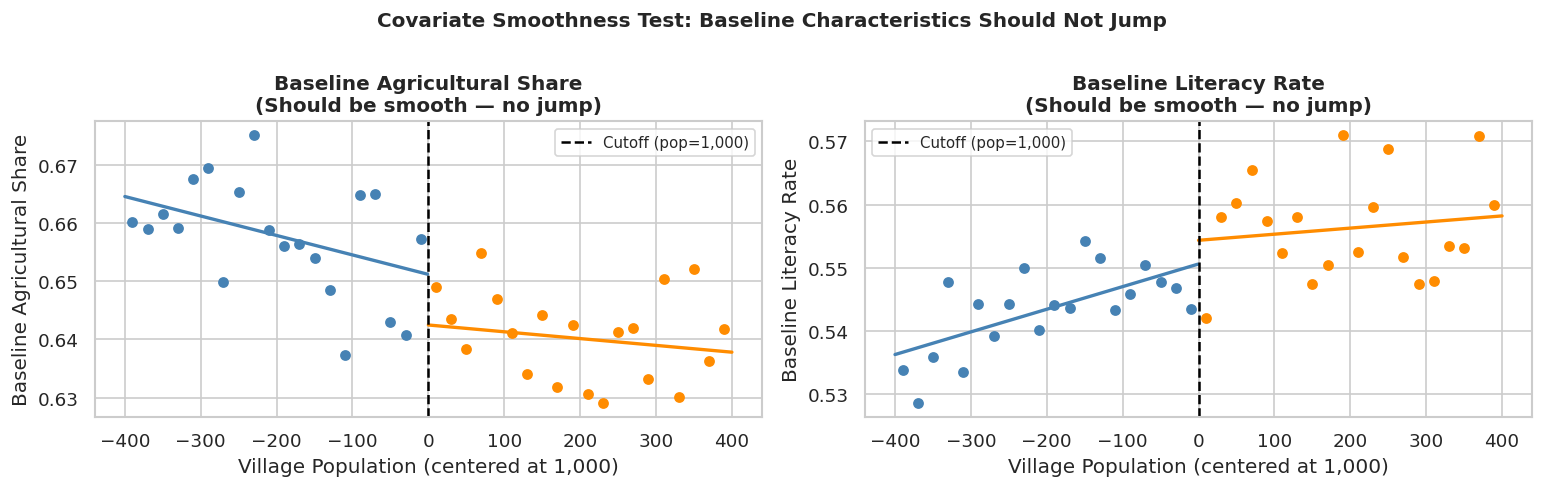

=== Covariate Balance: RDD Regressions on Baseline Variables ===
(Coefficient on treated should be near zero)

  Baseline Agricultural Share        : coef = -0.0041, p = 0.549
  Baseline Literacy Rate             : coef = +0.0065, p = 0.190

If p > 0.05 for all baseline variables: ✅ balance confirmed.


In [5]:
# Covariate balance: do pre-treatment characteristics jump at cutoff?
baseline_vars = {
    'baseline_agri'    : 'Baseline Agricultural Share',
    'baseline_literacy': 'Baseline Literacy Rate',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (var, label) in zip(axes, baseline_vars.items()):
    rdd_plot(df, var, CUTOFF, label,
             f'{label}\n(Should be smooth — no jump)', ax=ax)

plt.suptitle('Covariate Smoothness Test: Baseline Characteristics Should Not Jump',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Formal: RDD regression on baseline covariates
print('=== Covariate Balance: RDD Regressions on Baseline Variables ===')
print('(Coefficient on treated should be near zero)')
print()
bw = 300
data_bw = df[np.abs(df['pop_centered']) <= bw].copy()
for var, label in baseline_vars.items():
    m = smf.ols(f'{var} ~ treated * pop_centered', data=data_bw).fit()
    print(f'  {label:<35}: coef = {m.params["treated"]:+.4f}, p = {m.pvalues["treated"]:.3f}')
print()
print('If p > 0.05 for all baseline variables: ✅ balance confirmed.')

---
## Part 6: RDD Estimation — Local Linear Regression

The standard RDD estimator uses **local linear regression** — fitting a separate line on each side of the cutoff, within a bandwidth $h$.

$$Y_i = \alpha + \tau \cdot D_i + \beta_L (X_i - c) + \beta_R (X_i - c) \cdot D_i + \varepsilon_i$$

where:
- $D_i = \mathbf{1}[X_i \geq c]$ — treatment indicator
- $\tau$ — the RDD treatment effect (the jump at the cutoff)
- $\beta_L$, $\beta_R$ — slopes on each side (allowed to differ)

In [6]:
def rdd_estimate(df, outcome, bandwidth, cutoff=1000):
    data = df[np.abs(df['pop_centered']) <= bandwidth].copy()
    # Local linear with different slopes on each side
    m = smf.ols(f'{outcome} ~ treated * pop_centered', data=data).fit(
        cov_type='HC1')  # heteroskedasticity-robust SE
    return {
        'coef' : m.params['treated'],
        'se'   : m.bse['treated'],
        'p'    : m.pvalues['treated'],
        'n'    : len(data),
        'bw'   : bandwidth
    }

outcomes = {
    'nonfarm_share' : 'Non-Farm Employment Share',
    'agri_share'    : 'Agricultural Employment Share',
    'log_income'    : 'Log Household Income',
}

bw = 300  # main bandwidth
results = []
for var, label in outcomes.items():
    r = rdd_estimate(df, var, bw)
    stars = '***' if r['p']<0.01 else ('**' if r['p']<0.05 else ('*' if r['p']<0.1 else ''))
    results.append({
        'Outcome'     : label,
        'RDD Effect'  : round(r['coef'], 4),
        'SE'          : round(r['se'],   4),
        'p-value'     : round(r['p'],    3),
        'Sig'         : stars,
        'N'           : r['n'],
        'True Effect' : [TRUE_EFFECT_NONFARM, TRUE_EFFECT_AGRI, TRUE_EFFECT_INCOME][
                         list(outcomes.keys()).index(var)]
    })

res_df = pd.DataFrame(results)
print(f'=== RDD Results (bandwidth = ±{bw}) ===')
print()
print(res_df.to_string(index=False))
print()
print('*** p<0.01  ** p<0.05  * p<0.1')

=== RDD Results (bandwidth = ±300) ===

                      Outcome  RDD Effect     SE  p-value Sig    N  True Effect
    Non-Farm Employment Share      0.0763 0.0052    0.000 *** 2398         0.08
Agricultural Employment Share     -0.0558 0.0052    0.000 *** 2398        -0.06
         Log Household Income      0.0509 0.0250    0.042  ** 2398         0.00

*** p<0.01  ** p<0.05  * p<0.1


---
## Part 7: Bandwidth Sensitivity

The bandwidth $h$ is a key choice in RDD:
- **Too wide**: includes villages far from the cutoff that are less comparable — bias increases
- **Too narrow**: very few observations — variance increases

A robust finding should be stable across a range of bandwidths.

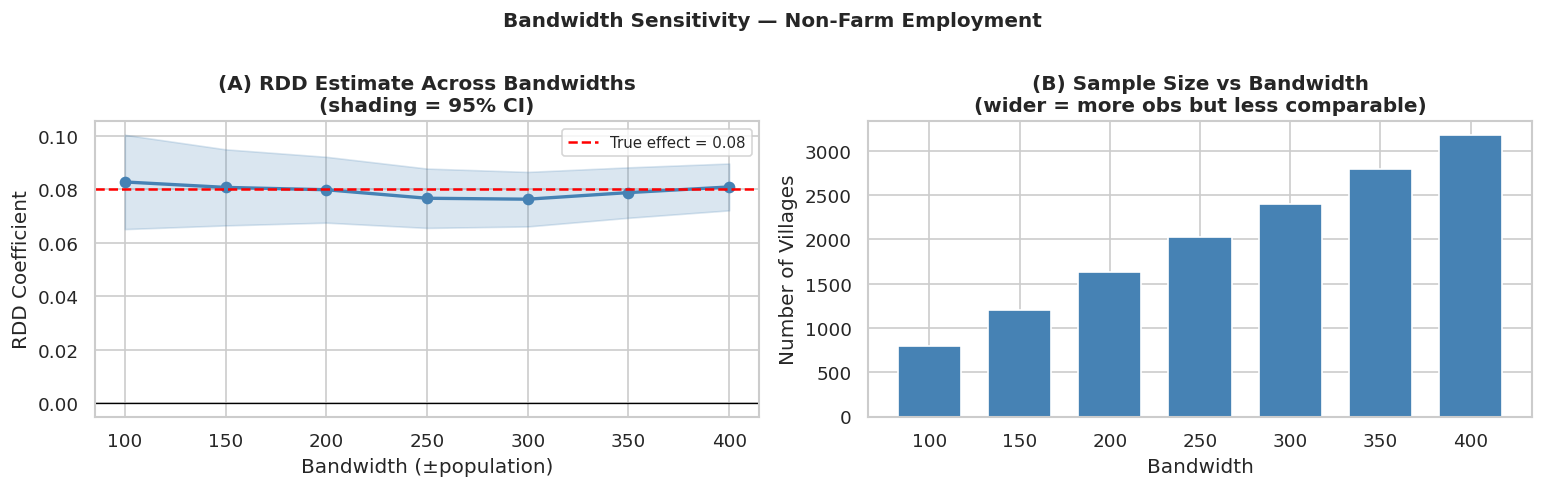

If estimates are stable across bandwidths → robust finding.


In [7]:
# Bandwidth sensitivity for non-farm employment
bandwidths = [100, 150, 200, 250, 300, 350, 400]
bw_results = [rdd_estimate(df, 'nonfarm_share', bw) for bw in bandwidths]

coefs = [r['coef'] for r in bw_results]
ses   = [r['se']   for r in bw_results]
ns    = [r['n']    for r in bw_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: coefficients with CI across bandwidths
axes[0].plot(bandwidths, coefs, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].fill_between(bandwidths,
                     [c - 1.96*s for c,s in zip(coefs,ses)],
                     [c + 1.96*s for c,s in zip(coefs,ses)],
                     alpha=0.2, color='steelblue')
axes[0].axhline(TRUE_EFFECT_NONFARM, color='red', linestyle='--',
                linewidth=1.5, label=f'True effect = {TRUE_EFFECT_NONFARM:.2f}')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Bandwidth (±population)')
axes[0].set_ylabel('RDD Coefficient')
axes[0].set_title('(A) RDD Estimate Across Bandwidths\n(shading = 95% CI)', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: sample size vs bandwidth
axes[1].bar(bandwidths, ns, color='steelblue', edgecolor='white', width=35)
axes[1].set_xlabel('Bandwidth')
axes[1].set_ylabel('Number of Villages')
axes[1].set_title('(B) Sample Size vs Bandwidth\n(wider = more obs but less comparable)',
                  fontweight='bold')

plt.suptitle('Bandwidth Sensitivity — Non-Farm Employment',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('If estimates are stable across bandwidths → robust finding.')

---
## Part 8: Placebo Test — Fake Cutoffs

A strong robustness check: run the RDD at **fake cutoffs** (e.g. population = 700 or 1,300). There should be **no jump** at a fake cutoff — only the real cutoff should produce a discontinuity.

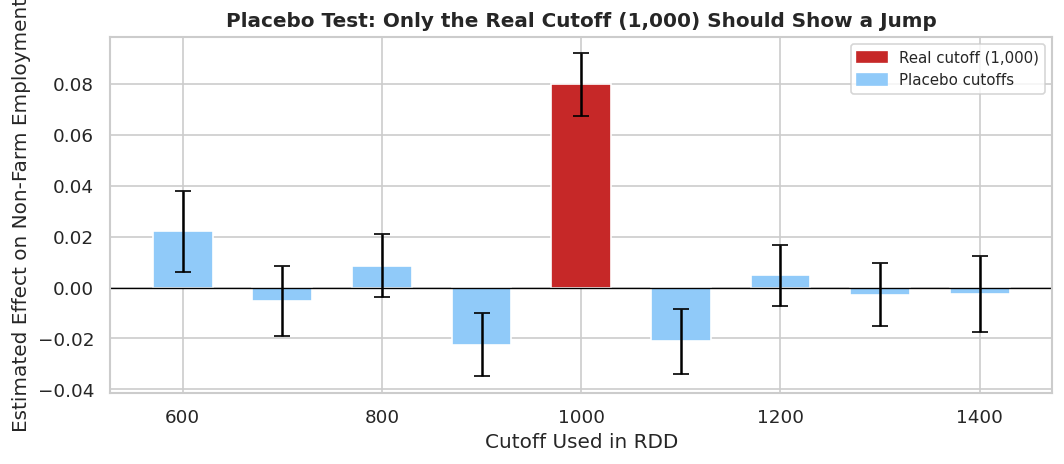

Effect at real cutoff (1,000):    0.0799
Mean |effect| at placebo cutoffs: 0.0112

The real cutoff should produce a much larger jump than the placebos.


In [8]:
# Placebo tests: fake cutoffs
placebo_cutoffs = [600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400]
placebo_results = []

for c in placebo_cutoffs:
    df_p = df.copy()
    df_p['pop_centered_p'] = df_p['population'] - c
    df_p['treated_p']      = (df_p['population'] >= c).astype(int)
    data_p = df_p[np.abs(df_p['pop_centered_p']) <= 200].copy()
    if len(data_p) < 100:
        continue
    m = smf.ols('nonfarm_share ~ treated_p * pop_centered_p', data=data_p).fit(cov_type='HC1')
    placebo_results.append({
        'cutoff': c,
        'coef'  : m.params['treated_p'],
        'se'    : m.bse['treated_p'],
        'real'  : (c == CUTOFF)
    })

pl_df = pd.DataFrame(placebo_results)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#C62828' if r else '#90CAF9' for r in pl_df['real']]
ax.bar(pl_df['cutoff'], pl_df['coef'], color=colors, edgecolor='white', width=60)
ax.errorbar(pl_df['cutoff'], pl_df['coef'], yerr=1.96*pl_df['se'],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cutoff Used in RDD')
ax.set_ylabel('Estimated Effect on Non-Farm Employment')
ax.set_title('Placebo Test: Only the Real Cutoff (1,000) Should Show a Jump',
             fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C62828', label='Real cutoff (1,000)'),
                   Patch(color='#90CAF9', label='Placebo cutoffs')], fontsize=9)
plt.tight_layout()
plt.show()

real_coef    = pl_df[pl_df['real']]['coef'].values[0]
placebo_mean = pl_df[~pl_df['real']]['coef'].abs().mean()
print(f'Effect at real cutoff (1,000):    {real_coef:.4f}')
print(f'Mean |effect| at placebo cutoffs: {placebo_mean:.4f}')
print()
print('The real cutoff should produce a much larger jump than the placebos.')

---
## Part 9: Summary Table — Main Results

In [9]:
# Final table: results across bandwidths for main outcomes
print('=== Main RDD Results: Effect of Rural Roads ===')
print('Asher & Novosad (AER, 2020) — Synthetic Replication')
print()
print(f'{"Outcome":<35} {"BW=200":>8} {"BW=300":>8} {"BW=400":>8} {"True":>8}')
print('-' * 62)

true_effects = [TRUE_EFFECT_NONFARM, TRUE_EFFECT_AGRI, TRUE_EFFECT_INCOME]
for (var, label), true in zip(outcomes.items(), true_effects):
    row = f'{label:<35}'
    for bw in [200, 300, 400]:
        r = rdd_estimate(df, var, bw)
        stars = '***' if r['p']<0.01 else ('**' if r['p']<0.05 else ('*' if r['p']<0.1 else ''))
        row += f' {r["coef"]:>6.3f}{stars:1s}'
    row += f' {true:>8.3f}'
    print(row)

print()
print('*** p<0.01  ** p<0.05  * p<0.1')
print()
print('Paper findings (Asher & Novosad, 2020):')
print('  Non-farm employment: INCREASES — roads move workers out of agriculture')
print('  Agricultural employment: DECREASES — structural transformation')
print('  Household income: NO SIGNIFICANT EFFECT — roads improve mobility but not income')

=== Main RDD Results: Effect of Rural Roads ===
Asher & Novosad (AER, 2020) — Synthetic Replication

Outcome                               BW=200   BW=300   BW=400     True
--------------------------------------------------------------
Non-Farm Employment Share            0.080***  0.076***  0.081***    0.080
Agricultural Employment Share       -0.060*** -0.056*** -0.053***   -0.060
Log Household Income                 0.073**  0.051**  0.028     0.000

*** p<0.01  ** p<0.05  * p<0.1

Paper findings (Asher & Novosad, 2020):
  Non-farm employment: INCREASES — roads move workers out of agriculture
  Agricultural employment: DECREASES — structural transformation
  Household income: NO SIGNIFICANT EFFECT — roads improve mobility but not income


---
## Summary

### The RDD Recipe

| Step | What you check | Python code |
|------|---------------|-------------|
| 1. Identify design | Running variable, cutoff, treatment | — |
| 2. RDD plot | Visual jump at cutoff | `ax.scatter` + `smf.ols` by side |
| 3. Density test | No bunching at cutoff | `ax.hist` + t-test |
| 4. Covariate balance | Baseline vars smooth at cutoff | `smf.ols` on baseline vars |
| 5. Estimate | Local linear regression | `smf.ols('Y ~ D * X_c')` |
| 6. Bandwidth sensitivity | Stable across bandwidths | Loop over bandwidths |
| 7. Placebo test | No jump at fake cutoffs | Loop over fake cutoffs |

### Key Concepts

- **Running variable**: the continuous variable that determines treatment (population)
- **Cutoff**: the threshold that assigns treatment (1,000 residents)
- **Local randomization**: near the cutoff, treatment is as-good-as-random
- **LATE**: RDD estimates the effect for villages **near the cutoff** — not all villages
- **Bandwidth**: trade-off between bias (wide) and variance (narrow)
- **Fuzzy RDD**: when the cutoff predicts but does not perfectly determine treatment — requires IV in the second stage (Asher & Novosad's actual design)

### The Policy Lesson

Rural roads facilitate **structural transformation** — workers move from agriculture to non-farm employment. But roads alone do not raise incomes in the short run. Market access is necessary but not sufficient for development — remote areas may still lack the economic opportunities needed to translate mobility into prosperity.

---
*ECON N171 | Summer 2026*